# Heart Disease Dataset Analysis
## Goal
Explore potential patterns related to heart disease.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:

df = pd.read_csv(r"C:\Users\49157\OneDrive\Projekts\heart-disease-analysis\data\raw\heart.csv")

In [4]:
df_clean = df.drop_duplicates().reset_index(drop=True)

# Feature Overview

- age: age of patient
- sex: gender (0 = female, 1 = male)
- cp: chest pain type
- trestbps: resting blood pressure
- chol: cholesterol level
- fbs: fasting blood sugar
- restecg: resting electrocardiograhic results
- target: heart disease diagnosis
- thalach: maximum heart rate achived
- exang: exercise induced angina (1=yes; 0=no)
- oldpeak: ST depression induced by exercise relative to rest
- ca: number of major vessels (0-3)
- thal: 1 = normal; 2 = fixed defect; 3 = reversable defect


# Feature Categories

## Numerical Features
- age
- trestbps
- chol
- thalach
- oldpeak

## Categorical Features
- sex
- cp
- fbs
- restecg
- exang
- slope
- ca
- thal
- target

| Feature  | Corr(Target) | strengths gues |
| -------- | ------------ | ------------   |
| exang    | -0.44        | strong         |
| oldpeak  | -0.44        | strong         |
| cp       | 0.43         | strong         |
| thalach  | 0.42         | strong         |
| ca       | -0.38        | medium         |
| slope    | 0.35         | medium         |
| thal     | -0.34        | medium         |
| age      | -0.23        | weak           |
| trestbps | -0.14        | weak           |


In [ ]:
df.head()

In [ ]:
df.info()

# Duplicate check

In [9]:
df.duplicated().sum()

np.int64(723)

In [10]:
print("original rows:", len(df))
print("Duplicated rows:", df.duplicated().sum())
print("Uniqe rows:", len(df.drop_duplicates()))

original rows: 1025
Duplicated rows: 723
Uniqe rows: 302


In [6]:
df.value_counts().head(10)

age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  target  age_group
38   1    2   138       175   0    1        173      0      0.0      2      4   2     1       (30, 40]     8
40   1    0   152       223   0    1        181      0      0.0      2      0   3     0       (30, 40]     4
              110       167   0    0        114      1      2.0      1      0   3     0       (30, 40]     4
41   1    1   120       157   0    1        182      0      0.0      2      0   2     1       (40, 50]     4
71   0    0   112       149   0    1        125      0      1.6      1      0   2     1       (70, 80]     4
          2   110       265   1    0        130      0      0.0      2      1   2     1       (70, 80]     4
39   1    0   118       219   0    1        140      0      1.2      1      0   3     0       (30, 40]     4
64   1    0   120       246   0    0        96       1      2.2      0      1   2     0       (60, 70]     4
          2   125       

In [7]:
df["target"].value_counts(normalize=True)

target
1    0.513171
0    0.486829
Name: proportion, dtype: float64

In [8]:
df.drop_duplicates()["target"].value_counts(normalize=True)

target
1    0.543046
0    0.456954
Name: proportion, dtype: float64

## Duplicate observations

The original dataset contains 1,025 observations, of which 723 are exact
duplicates. After removing these duplicates, 302 unique observations remain.

The target distribution changes from 51.3% positive cases in the original
dataset to 54.3% after duplicate removal. This indicates that duplicate
observations were not distributed equally across both target classes.

The duplicates were removed before further analysis and modeling to avoid
inflated subgroup sizes, distorted statistics, and potential data leakage.

In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


The dataset consists of approximately 69.56% male and 30.44% female participants. However, this distribution alone does not provide any information about the prevalence of heart disease among men and women. Further analysis is required to examine the relationship between sex and the target variable.

#### Heatmap

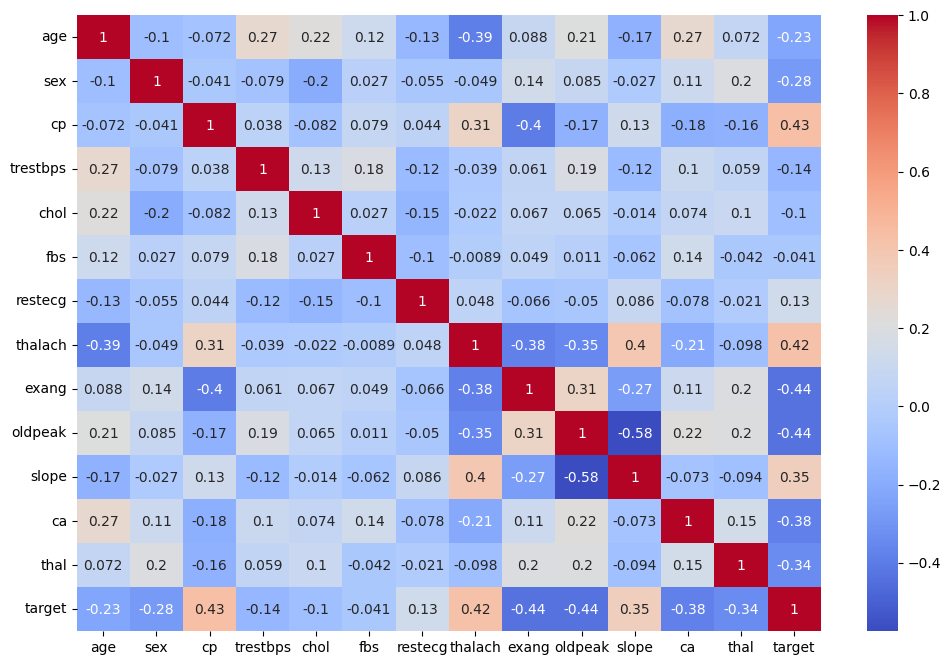

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

# Through this heatmap, we can observe that the only three features showing a moderately strong positive correlation with the target value are slope, thalach, and cp. Meanwhile, exang and oldpeak show a moderately strong negative correlation. We cannot draw any real conclusions based solely on this information, but it is worth taking a deeper look at these variables.

In [ ]:
df.shape

In [4]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [ ]:
df.isnull().sum()

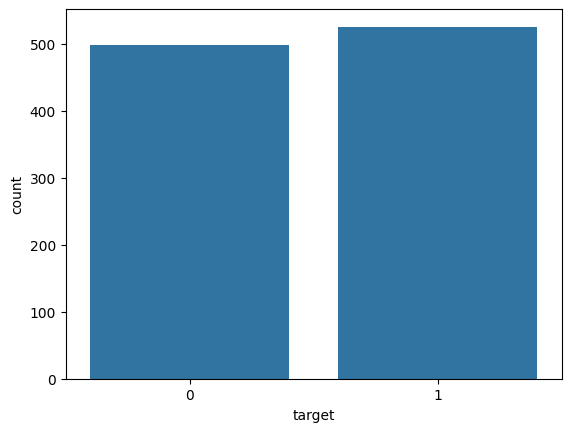

In [3]:
sns.countplot(x="target", data= df)
plt.show()

In [4]:
counts = df["target"].value_counts()
percentages = (df["target"].value_counts(normalize=True) * 100).round(2)

summary = pd.DataFrame({
    "Count": counts,
    "Percentage": percentages
})

print(summary)

        Count  Percentage
target                   
1         526       51.32
0         499       48.68


In [10]:
pd.crosstab(df["sex"],df["target"], normalize="index",)

target,0,1
sex,,
0,0.275641,0.724359
1,0.579243,0.420757


In [8]:
df.groupby("target").mean(numeric_only=True)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
target,,,,,,,,,,,,,
0,56.569138,0.827655,0.482966,134.106212,251.292585,0.164329,0.456914,139.130261,0.549098,1.600200,1.166333,1.158317,2.539078
1,52.408745,0.570342,1.378327,129.245247,240.979087,0.134981,0.598859,158.585551,0.134981,0.569962,1.593156,0.370722,2.119772


#### Age 

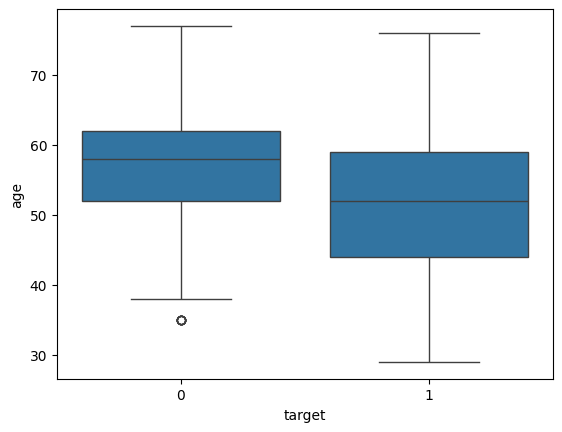

In [10]:
sns.boxplot(x="target", y="age", data=df)
plt.show()

# Patients with target=1 tend to be younger than patients with target=0 in this dataset, although the distributions overlap substantially. which at first glance is a bit surprising. However, if we take a look at the heatmap, we can see that the correlation between age and target is -0.23. Therefore, this boxplot aligns well with the heatmap and appears to confirm the observed relationship. That said, it does not necessarily mean that younger people are more prone to heart disease than older people.

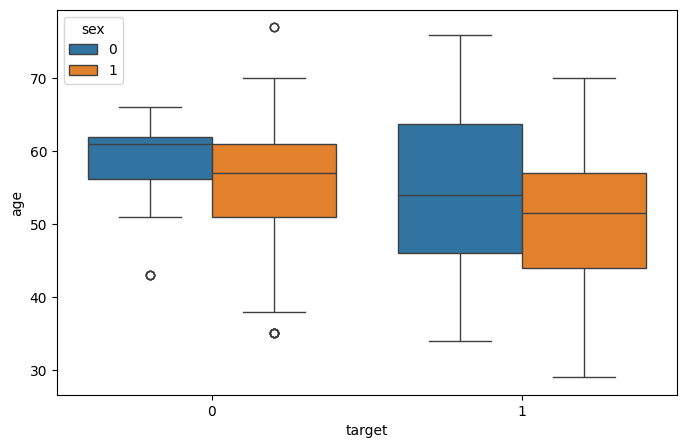

In [3]:
plt.figure(figsize=(8,5))
sns.boxplot(x="target", y="age", hue="sex", data=df)
plt.show()

# If we include the sex variable in this analysis, we can see that the overall range for women in target = 0 is visibly smaller than for men. Additionally, for men in target = 0, there are two outliers, while for women in target = 0, there is one outlier. However, these may simply represent rare medical cases.

On the other hand, we can see that women in target = 1 have a larger IQR than men in target = 1. The medians for both groups are relatively close, but the overall age range for women starts and ends at higher values than for men. This may suggest a potential interaction between age and sex, although further statistical analysis would be required to confirm this relationship.

C:\Users\49157\AppData\Local\Temp\ipykernel_33884\368925107.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prob = (df.groupby(["sex", "age_group"])["target"]).mean().reset_index()


<Axes: xlabel='age_group', ylabel='target'>

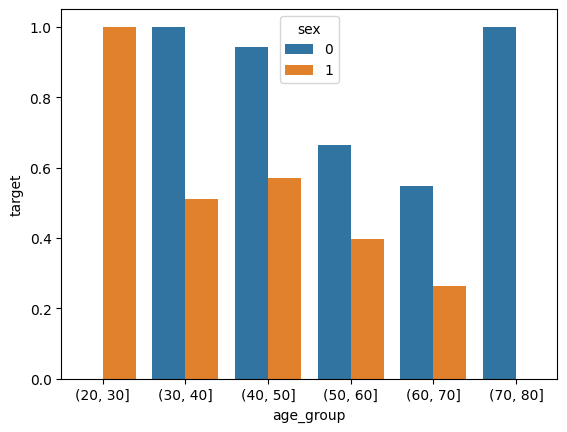

In [3]:
df["age_group"] = pd.cut(df["age"], bins=[20,30,40,50,60,70,80])

prob = (df.groupby(["sex", "age_group"])["target"]).mean().reset_index()

sns.barplot(data=prob, x="age_group", y="target", hue="sex")

In [9]:
pd.crosstab(
    [df["sex"], df["age_group"]],
    df["target"]
)

target           0    1
sex age_group          
0   (30, 40]     0   17
    (40, 50]     4   64
    (50, 60]    38   75
    (60, 70]    44   53
    (70, 80]     0   17
1   (20, 30]     0    4
    (30, 40]    23   24
    (40, 50]    77  102
    (50, 60]   196  129
    (60, 70]   114   41
    (70, 80]     3    0

# The relationship between age group, sex, and heart disease appears to differ across age intervals.

However, some age groups contain only a small number of observations, which leads to unstable probabilities (e.g., 0% or 100%).

Overall, the data suggests that age and sex may interact with each other, but larger sample sizes would be required before drawing stronger conclusions.

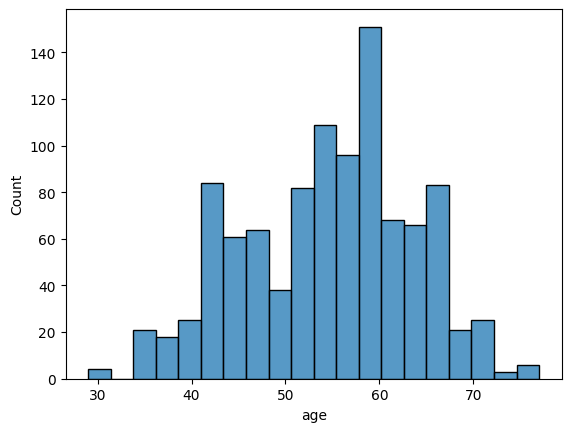

In [8]:
sns.histplot(df["age"], bins=20)
plt.show()

## Age Distribution Findings

- Mean age is approximately 54
- Median age is 56
- Most patients are between 45 and 65 years old
- Distribution appears roughly normal with slight concentration around the mid-50s
- No extreme outliers detected visually

#### Cholesterol

<Axes: xlabel='target', ylabel='chol'>

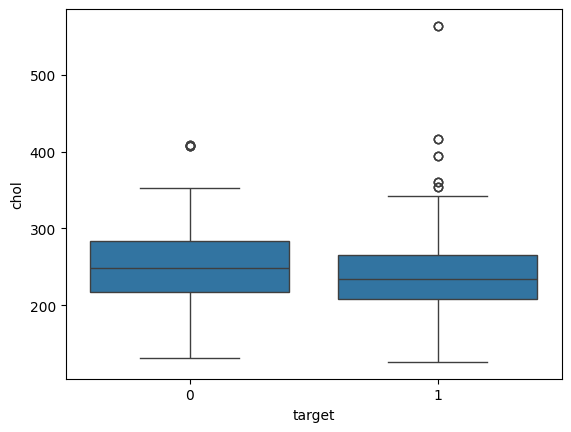

In [12]:
sns.boxplot(x="target", y="chol", data=df)

# In this boxplot, we can see that the medians for both groups (0 = no heart disease and 1 = heart disease) are relatively similar. Therefore, it seems that cholesterol levels are not a single major factor, which is also supported by the weak correlation observed in the heatmap.

# Another interesting observation is that the overall distributions are quite similar. This further strengthens the hypothesis that this variable alone is unlikely to be a strong predictive feature.

# However, there are several strong outliers, which could represent:
- real medical special cases
- data artifacts
- rare cases

#### Oldpeak

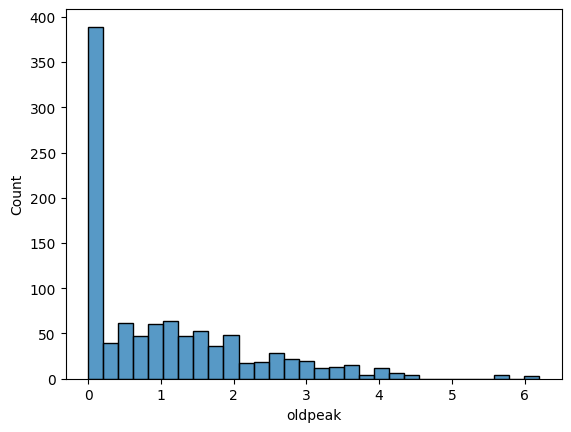

In [5]:
sns.histplot(df["oldpeak"], bins=30)
plt.show()

<Axes: xlabel='target', ylabel='oldpeak'>

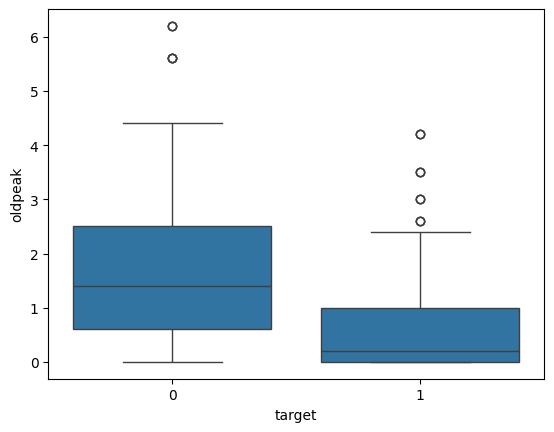

In [14]:
sns.boxplot(x="target", y="oldpeak", data=df)

#### Chest pain level

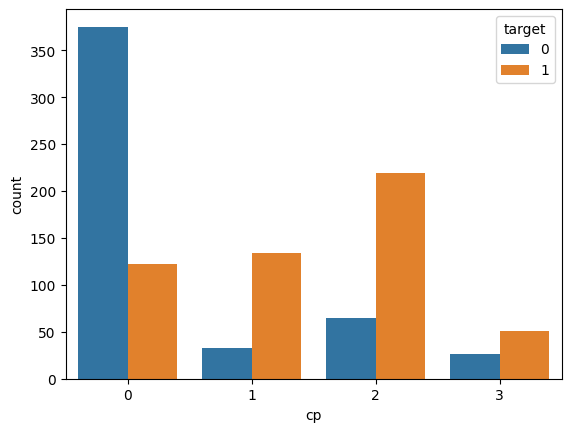

In [8]:
sns.countplot(x="cp",hue="target", data=df)
plt.show()

In [4]:
pd.crosstab(
    [df["sex"], df["cp"]],
    df["target"],
    normalize="index"
)

target         0         1
sex cp                    
0   0   0.563910  0.436090
    1   0.122807  0.877193
    2   0.036697  0.963303
    3   0.000000  1.000000
1   0   0.824176  0.175824
    1   0.236364  0.763636
    2   0.348571  0.651429
    3   0.406250  0.593750

## Chest Pain Type vs Target

The distribution suggests that some chest pain categories occur more frequently among patients with heart disease. This feature should be investigated further because it also showed a moderate positive correlation with the target variable.

#### Slope

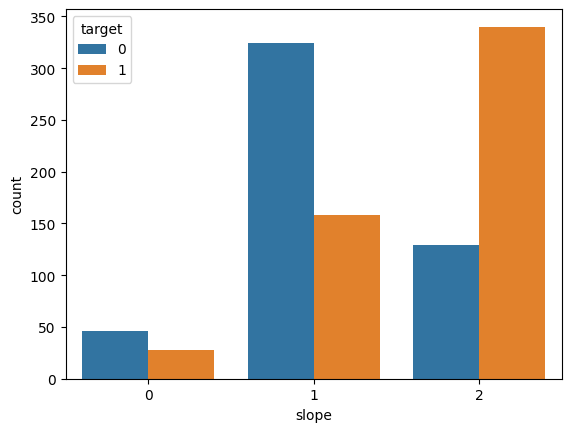

In [5]:
sns.countplot(x="slope", hue="target", data=df)
plt.show()

Slope appears to have a moderate relationship with the target variable.

Patients with slope value 2 seem to show a higher proportion of heart disease cases compared to other categories.

This observation is consistent with the moderate positive correlation (~0.35) shown in the correlation matrix.

In [8]:
pd.crosstab(
    [df["sex"], df["slope"]],
    df["target"],
    normalize="index"
)

target            0         1
sex slope                    
0   0      0.647059  0.352941
    1      0.446667  0.553333
    2      0.055172  0.944828
1   0      0.614035  0.385965
    1      0.774096  0.225904
    2      0.373457  0.626543

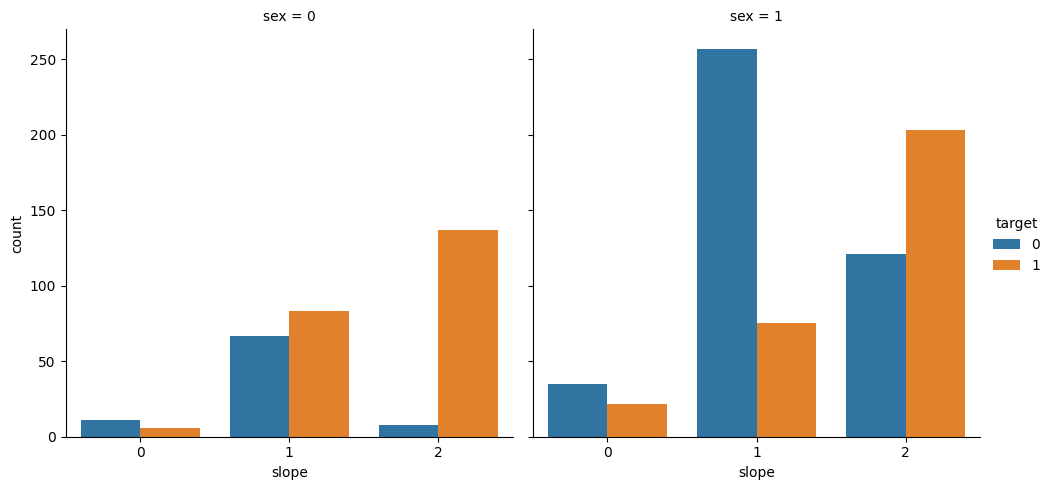

In [13]:
sns.catplot(
    x="slope",
    hue="target",
    col="sex",
    kind="count",
    data=df
)
plt.show()

## this catplot shows that Female patients with target=1 appear more frequently in the slope=2 category compared to other slope categories. And for the male cases majorty is recorded for upsloping, while for the 0 value target you can see that a big nummber of cases is recorded for flat sloping. But this dose not automaticly say that men with a flat slope value recorded are not vulnerable for heart diseases, there are simply more cases recorded for men then for women in this data set. 

#### trestbps

what am i looking for? 
- i am looking out for patterns in the restbps variable to ether strengens or reevalute past results
- looking for the results of the boxplots to see if they resonates with the heatmap correlation target <=> trestbps = -0.14

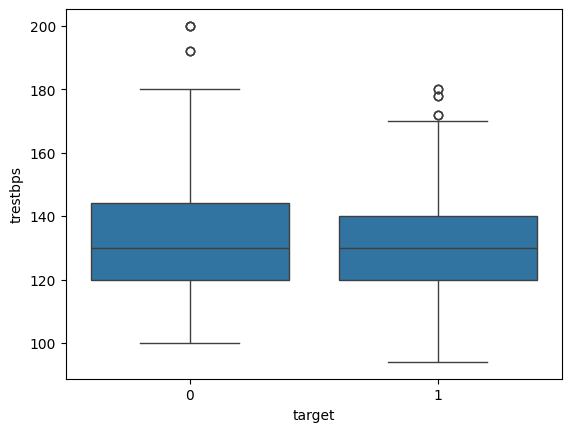

In [14]:
sns.boxplot(x="target", y="trestbps", data=df)
plt.show()

# in this boxplot you can observe that the median almost identical. That said we can see that there are diferences between target value 0 (no heart disease) and target value 1 (heart disease). the Interquartile range for value 1 is visibly smaller than the one for the value 0. this means that for value 1 the masuerd 50% is less spread then for the value 0. The distributions for both target groups overlap heavily. Although the target=1 group appears slightly more compact and marginally lower overall, the difference is relatively small. this corralte very well with the heatmap corralation value of -0.14. Several high blood pressure outliers are visible in both target groups.

These may represent:
- genuine high-risk patients
- naturally rare observations
- or potential recording anomalies

Further domain validation would be required before removing or modifying them.

overall we can see a difference between the two values but there are pretty small so this information should be treated with caution.


#### thalach

thalach hypothisis:

the maximum achived heart rate is a strong variable that could be a strong indicator on whether someone could be diagnosed with heart disease problems

## Qusestion 

how storng dose the maximum achieved heartrate differ between healty and ill patients

## Allready made observations

the heatmap showcase that target <=> thalach has a 0.42 postive correlation which is the second strongest after cp. 

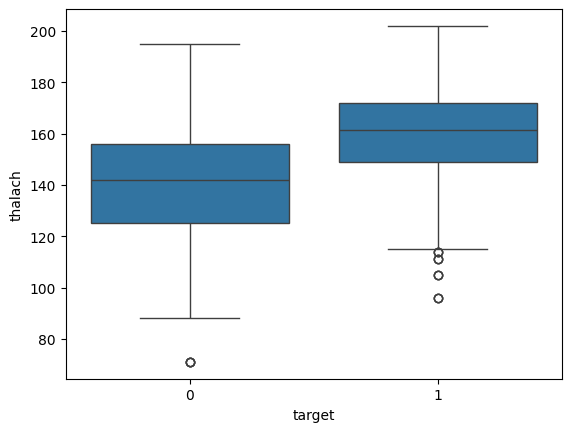

In [9]:
sns.boxplot(x="target", y="thalach", data=df)
plt.show()

# On this boxplot we can see that the median for target=1 is visibly higher then the the median for target=0. This strenghtens my hypotisis that thalach is a strong indicator, and also corralates very well with what the heatmap is showing. While there are visible outlieres for target one, the IRQs do not overlap a lot. Therefor the outliers could be some rare medical cases. It Still has to be said that this dose not say that a high maximum achieved heart rate is autimaticly a polluter for heart diseases.

##### Sex

# sex hypothesis:

Sex may have predictive value, either on its own or in combination with other variables

# Previous Observations

While analyzing other variables, I observed that sex appears to have an influence on the target value when considered as a secondary factor rather than as a standalone predictor.

# Question

Is sex on its own a strong indicator of heart disease?

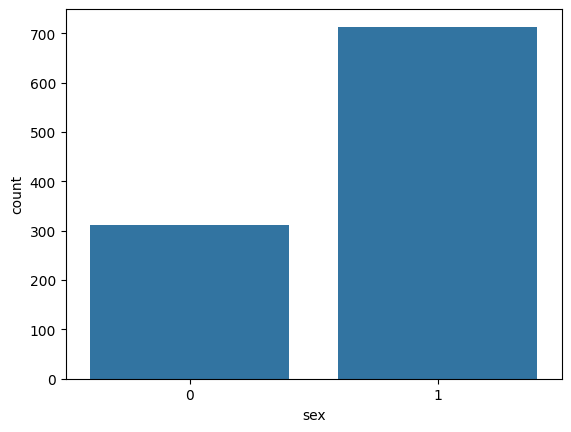

In [5]:
sns.countplot(x="sex",data=df)
plt.show()

In [9]:
df["sex"].value_counts()

sex
1    713
0    312
Name: count, dtype: int64

# Observation

Here, we can observe that the number of men in this dataset is more than twice the number of women. Therefore, we cannot simply conclude that one sex is more likely to have heart disease based on the raw counts alone.

For example, if 100 out of 300 women have heart disease and 200 out of 700 men have heart disease, the percentage of affected women would actually be higher despite the lower absolute number of cases.

Therefore, any comparison between men and women should be based on percentages rather than raw counts. Otherwise, the results may be misleading due to the unequal distribution of sexes within the dataset.

In [3]:
pd.crosstab(
    df["sex"],
    df["target"],
    normalize="index"
)

target,0,1
sex,,
0,0.275641,0.724359
1,0.579243,0.420757


<Axes: xlabel='sex', ylabel='count'>

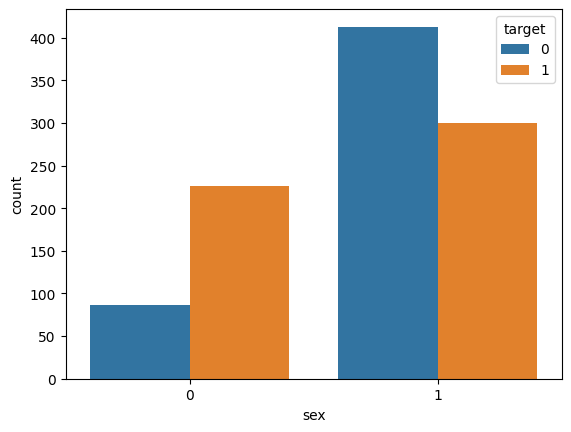

In [ ]:
sns.countplot(x="sex", 
    hue="target", 
    data=df
)

# The countplot and the crosstab, that for women 72.4% of the regestred have target value=1, while for men the precentage is at 42.07%. Thats a noticeble gap and it might indicate that in this dataset, female patients show a substantially higher proportion of target=1 observations than male patients.. The reason could be a smaller blood vessel or other mediacal cases, in any case a medical profesional or a docotor might be able to make a statement on this because i am simply working on the math and am not authorised to make medical statemts.

Sex appears to carry predictive information and should not be discarded without further investigation.
At any case this data suggests that this variable shuld be included in further studies or in for training ml models.

In [5]:
pd.crosstab([df["sex"], df["cp"]], df["target"], normalize="index")

target         0         1
sex cp                    
0   0   0.563910  0.436090
    1   0.122807  0.877193
    2   0.036697  0.963303
    3   0.000000  1.000000
1   0   0.824176  0.175824
    1   0.236364  0.763636
    2   0.348571  0.651429
    3   0.406250  0.593750

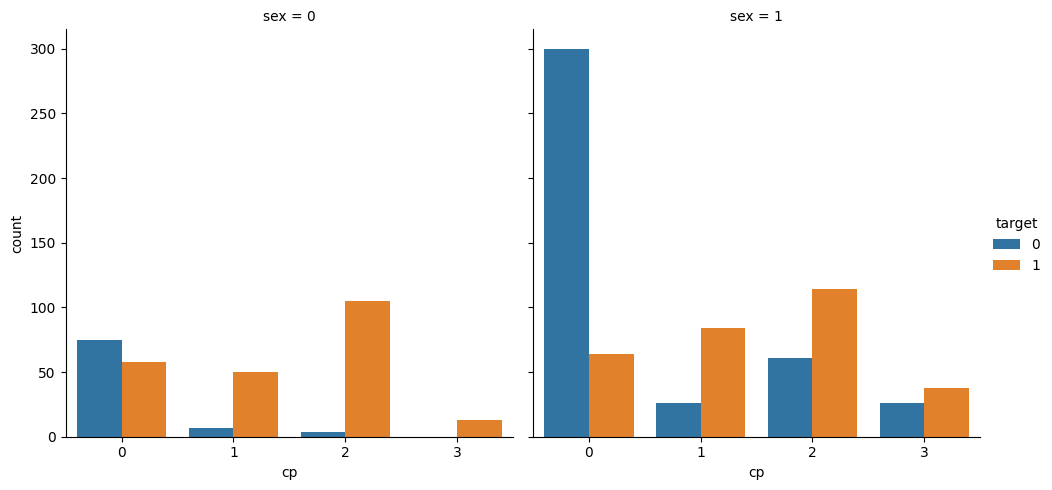

In [4]:
sns.catplot(
    x="cp",
    hue="target",
    col="sex",
    kind="count",
    data=df
)

# Here, we can observe something interesting when we include the **sex** variable in the analysis of the **cp** (chest pain type) variable. For **sex = 1** and **target = 1**, patients appear to be more evenly distributed across the different chest pain levels. In contrast, for **sex = 0** and **target = 1**, the distribution is less even.

Additionally, for **sex = 1** and **target = 0**, most observations appear to be concentrated at **cp = 0**.

Overall, These patterns may suggest that the relationship between chest pain type (cp) and heart disease differs between males and females, although further statistical analysis would be needed to confirm this observation.


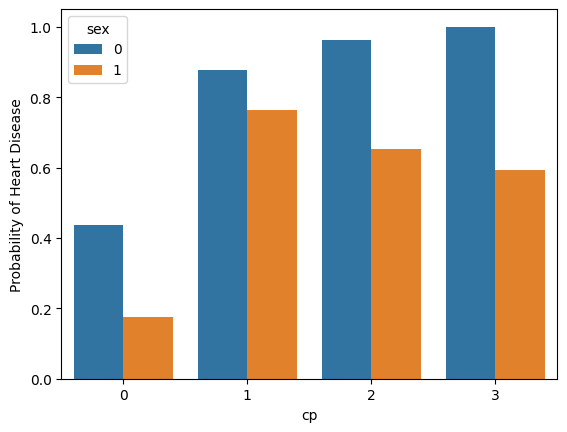

In [10]:
prob = (
    df
    .groupby(["sex", "cp"])["target"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=prob,
    x="cp",
    y="target",
    hue="sex"
)
plt.ylabel("Probability of Heart Disease")
plt.show()

In [9]:
pd.crosstab(
    [df["sex"], df["cp"]],
    df["target"]
)

target    0    1
sex cp          
0   0    75   58
    1     7   50
    2     4  105
    3     0   13
1   0   300   64
    1    26   84
    2    61  114
    3    26   38

# The probability of heart diseases in relation to cp and sex here is very interesting. It appears that fot sex=0 the overall probability is higher. But sex=0 cp=3 is particularly noteworthy and also seems unusual because it seems to be a appears to reach 100% in this sample which is conserning, but if you look at the crosstab you can see that this might be true for 13 patients. However, this result is based on only 13 observations and should therefore be interpreted with caution. Even so the cp variable appears to be a strong predictive feature especialy for sex=0, but with limitations to keep in mind.

#### exang

## Hypothesis

I want to investigate wether exercise-induced angina is associated with heart disease and whether this relationship differs between men and women.

## Observation

## Statistical Evidence

heatmap correlation exang<=>target = -0.44; 

## Interpretration

## Limitations

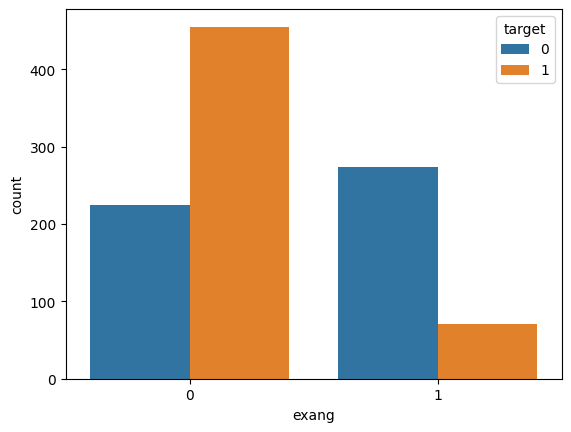

In [ ]:
sns.countplot(
    x="exang",
    hue="target",
    data=df
)

plt.show()

In [5]:
pd.crosstab(
    df["exang"],
    df["target"],
    normalize="index"
)

target,0,1
exang,,
0,0.330882,0.669118
1,0.794203,0.205797


The countplot and the crosstab show that 20.6% of the target=1 patients are in the exang=1 categorie. And 79.4% of the patients were documented for exang=0. This observation is consistent with the negative correlation observed in the heatmap.

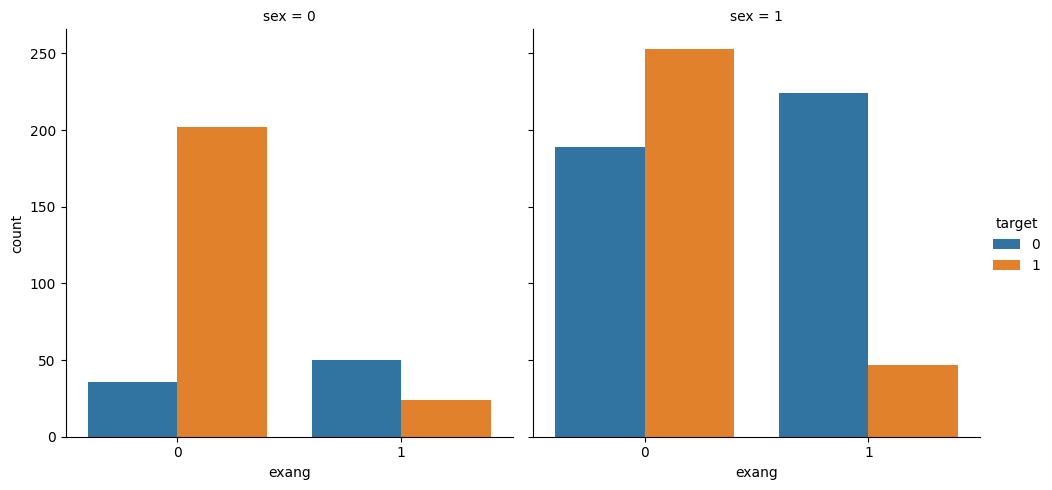

In [3]:
sns.catplot(
    x="exang",
    hue="target",
    col="sex",
    kind="count",
    data=df
)

plt.show()

In [4]:
pd.crosstab(
    [df["sex"], df["exang"]],
    df["target"]
)

target       0    1
sex exang          
0   0       36  202
    1       50   24
1   0      189  253
    1      224   47

In [3]:
pd.crosstab(
    [df["sex"], df["exang"]],
    df["target"],
    normalize="index"
)

target            0         1
sex exang                    
0   0      0.151261  0.848739
    1      0.675676  0.324324
1   0      0.427602  0.572398
    1      0.826568  0.173432

## The crosstab suggests that sex influences the relationship between exercise-induced angina (`exang`) and heart disease (`target`).

For women (`sex = 0`), the difference between `exang = 0` and `exang = 1` is particularly pronounced. Among women with `exang = 1`, only 32.4% have `target = 1`, whereas the corresponding proportion for `exang = 0` is 84.9%.

A similar pattern can be observed for men, although the difference is less pronounced (57.2% vs. 17.3%).

Overall, these findings suggest a possible interaction between `sex` and `exang`, indicating that the predictive value of `exang` may differ by sex.

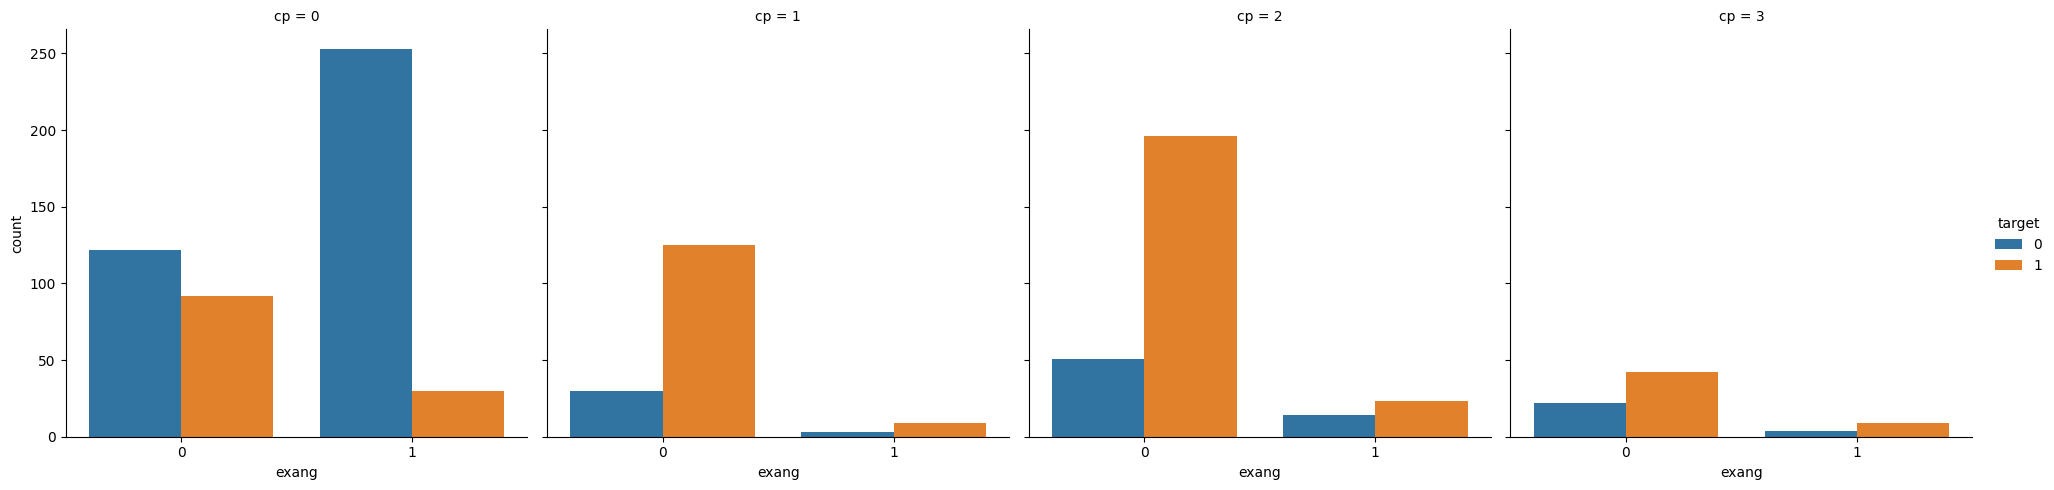

In [4]:
sns.catplot(
    x="exang",
    hue="target",
    col="cp",
    kind="count",
    data=df
)

plt.show()

In [4]:
counts = pd.crosstab(
    [df["cp"], df["exang"]],
    df["target"],
)

counts

target      0    1
cp exang          
0  0      122   92
   1      253   30
1  0       30  125
   1        3    9
2  0       51  196
   1       14   23
3  0       22   42
   1        4    9

In [5]:
rates = pd.crosstab(
    [df["cp"], df["exang"]],
    df["target"],
    normalize="index"
)

rates

target           0         1
cp exang                    
0  0      0.570093  0.429907
   1      0.893993  0.106007
1  0      0.193548  0.806452
   1      0.250000  0.750000
2  0      0.206478  0.793522
   1      0.378378  0.621622
3  0      0.343750  0.656250
   1      0.307692  0.692308

## Interaction between cp and exang

The heatmap shows a negative correlation of approximately -0.44 between
`exang` and `target`. However, the relationship appears to vary across the
different chest pain categories.

Among patients with `cp = 0`, the proportion of `target = 1` decreases from
42.9% for `exang = 0` to 10.6% for `exang = 1`.

A similar but weaker pattern can be observed for `cp = 1` and `cp = 2`.
For `cp = 3`, the pattern is slightly reversed, with 69.2% of patients with
`exang = 1` having `target = 1`, compared with 65.6% for `exang = 0`.

These findings suggest a possible interaction between `cp` and `exang`.
However, the subgroup sizes should be examined before drawing stronger
conclusions.

Cleard Data


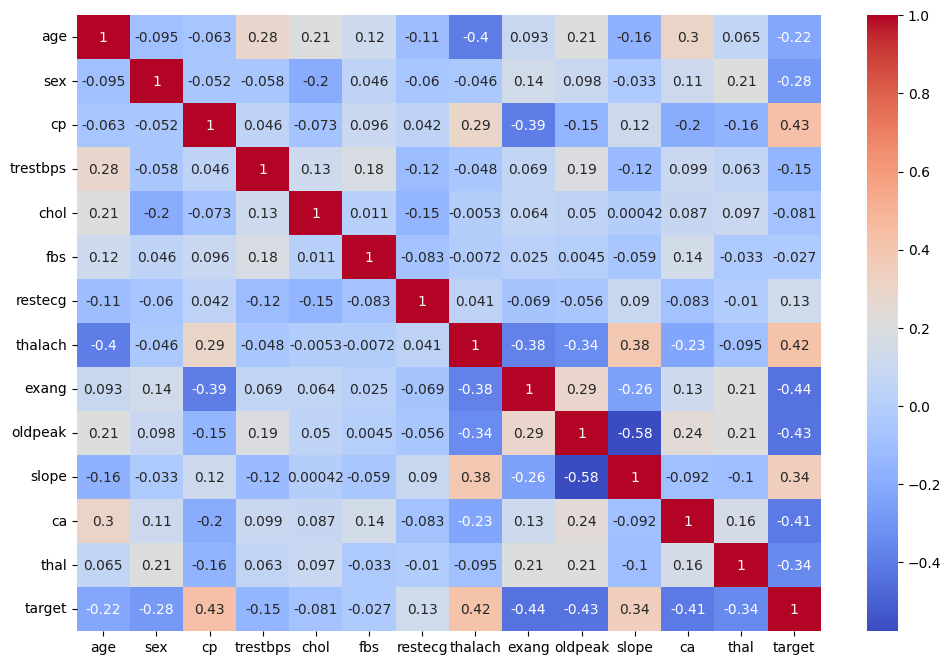

In [5]:
plt.figure(figsize=(12,8))
sns.heatmap(df_clean.corr(), annot=True, cmap="coolwarm")
plt.show()

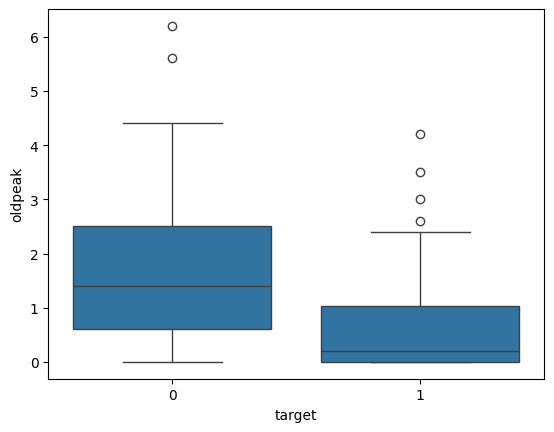

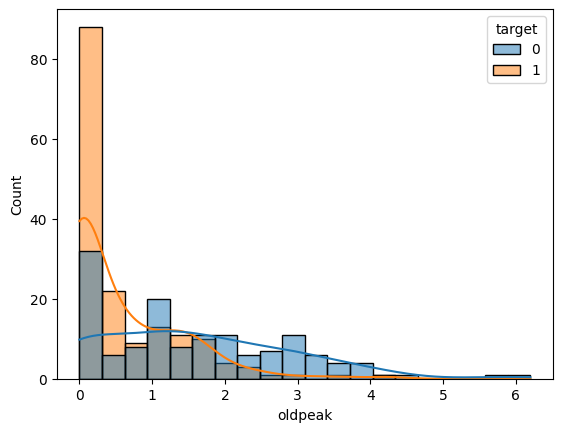

In [5]:
sns.boxplot(data=df_clean, x="target", y="oldpeak")
plt.show()

sns.histplot(
    data=df_clean,
    x="oldpeak",
    hue="target",
    bins=20,
    kde=True
)
plt.show()